In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import warnings
import pandas as pd
import sys; sys.path.insert(0, '..')

from src.modified_sampling import *

warnings.simplefilter(action ='ignore', category = pd.errors.PerformanceWarning)
warnings.filterwarnings('ignore', category = RuntimeWarning)
warnings.filterwarnings('ignore', category = UserWarning)

In [3]:
# Import data
df = pd.read_parquet(
    '../data/processed/behaviour_factors.parquet',
    engine = 'pyarrow'
)

# Show table
df.head(5)

,APPLICATION_NUMBER,BRANCH,RESTRUCTURE_FLAG,pay_types,bal,CONTRACT_STATUS,TOTAL_TERM,OVERDUE_DAYS,CONTRACT_ID,CUSTOMER_NUMBER,...,del_60_run_9,del_90_run_9,del_x_run_6,del_30_run_6,del_60_run_6,del_90_run_6,del_x_run_3,del_30_run_3,del_60_run_3,del_90_run_3
0,944370,A,N,1,507120.0,10,60.0,0,944370,6626063,...,0,0,0,0,0,0,0,0,0,0
1,944370,A,N,2,498668.0,10,60.0,0,944370,6626063,...,0,0,0,0,0,0,0,0,0,0
2,944370,A,N,2,490216.0,10,60.0,0,944370,6626063,...,0,0,0,0,0,0,0,0,0,0
3,944370,A,N,2,481764.0,10,60.0,0,944370,6626063,...,0,0,0,0,0,0,0,0,0,0
4,944370,A,N,2,473312.0,10,60.0,0,944370,6626063,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Keep records
TOTAL_N = df.shape[0]
MAX_MONTH = df['Monthkey'].max()

# Constant parameters
ID_COL = 'Br_Con' #Primary key
PERIOD_COL = 'Monthkey' #Date key
N_LAGS = 6 #Performance windows
DEFAULT_COL = 'del' #Default column
DEFAULT_FLAG = 3 #Any values greater than this value will be considered as default

# ========================================= #
# Default definition is 60+ DPD in 6 months #
# ========================================= #

# Define default label
DEFAULT_LABEL = ["defX", "def30", "def60", "def90"][DEFAULT_FLAG - 1] if 1 <= DEFAULT_FLAG <= 4 else None

In [5]:
# Prepare dataset
steps = [
    ('Sorting and flag default', lambda d: prepare_dataframe(
        d, id_col = ID_COL, period_col = PERIOD_COL, default_col = DEFAULT_COL, default_flag = DEFAULT_FLAG
    )),
    ('Forward performance and ever default', lambda d: forward_ever_default(
        d, id_col = ID_COL, default_col = DEFAULT_LABEL, n_lags = N_LAGS
    ))
]

for _, step_fn in steps:
    df = step_fn(df)

=== Processing ===
[Sort and create default flag]
=== Processing ===
[Forward performance windows and ever default]


In [6]:
# Exclusion criteria
"""
Rules:
    1. Newly originated contract
        - 12 months observation windows is used to create behavioral factors.
        - Any contracts with less than 12 months are invalid since the observation windows is not fulfilled.
    2. MOB < 12
        - 12 months observation windows is used to create behavioral factors.
        - Any transaction with less than 12 MOB is excluded from development samaple.
    3. Bad at observation point
        - Defaulted transaction must be excluded.
        - Modeling the probability of performing to non-performing (Defaualt rate or Probability of Default; PD)
        - Any DPD greater than 60 DPD will be excluded.
    4. Less than 6 months forward performance window
        - Default definition is 60+ DPD in 6 months meaning the last 6 months are invalid.
        - Any transactions of last 6 months are excluded from development samaple. 
    5. Last transaction
        - No probability to observed
        - Any transactions have no next month are excluded from development samaple. 
"""

# Find only valid contracts
valid_id = find_valid_contract(df, id_col = ID_COL, period_col = ['MOB', 'Monthkey'])

# Keep log records and exclusion
excluded_logs = [['Original', len(df), 0]] #Original transaction
excluded_steps = {
    "Newly originated contract": "Br_Con in @valid_id",
    "MOB less than 12": "MOB >= 12",
    "Existing default": "def60 != 1",
    "Last 6 months performance": "Monthkey <= @MAX_MONTH - 6",
    "Last transaction": "def601.notnull()"
}

# Exclusion
print("=== Processing ===\n[Exclusion]")
n_steps = len(excluded_steps) #Total exclusion steps

for i, (step, criteria) in enumerate(excluded_steps.items(), start = 1):
    n_before = len(df)
    df = df.query(criteria)
    n_after = len(df)
    print(f"[✓] {step:<30}: {n_before - n_after:<6} transactions")
    excluded_logs.append([step, n_before, n_after])
    is_last = (i == n_steps)
    if is_last:
        excluded_logs.append(['Final', n_after, 0])

# Drop unused columns
df = drop_cols(df, default_col = 'def60', n_lags = N_LAGS)


=== Processing ===
[Exclusion]
[✓] Newly originated contract     : 41972  transactions
[✓] MOB less than 12              : 245461 transactions
[✓] Existing default              : 11093  transactions
[✓] Last 6 months performance     : 69443  transactions
[✓] Last transaction              : 4777   transactions


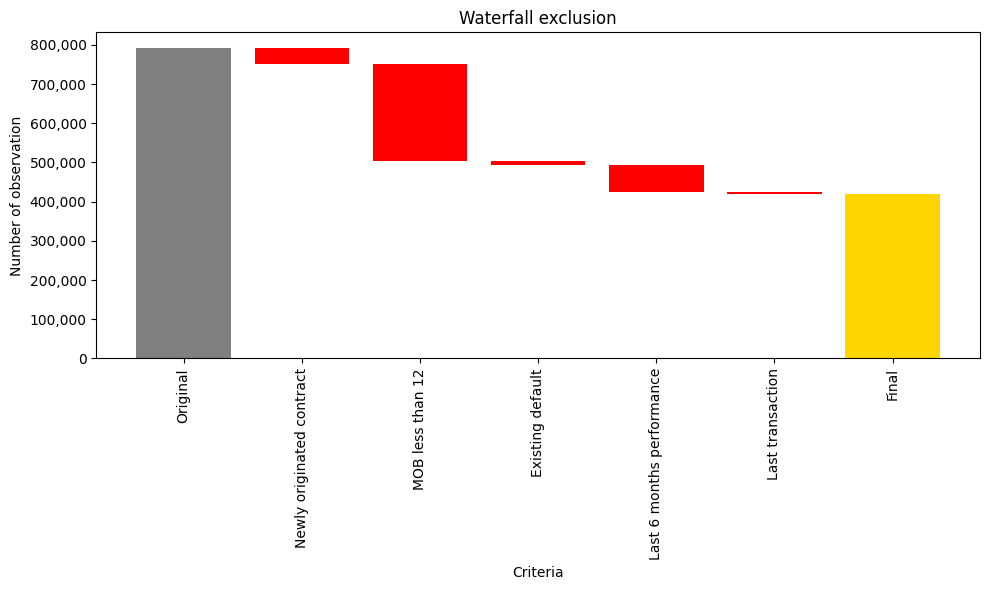

In [7]:
# Plot waterfall summary
plot_exclusion(excluded_logs)

In [17]:
# Train/Test Split
train, test = modified_train_test(
    data = df,
    id_col = ID_COL,
    default_col = 'ever_default_6',
    period_col = PERIOD_COL,
    test_size = 0.3,
    threshold1 = 0.001, #For overall ODR
    threshold2 = 0.01, #For monthly ODR
    max_iter = 1000,
    random_state = 42,
    n_jobs = -1,
    batch_size = 50,
    patience = 100
)

=== Processing ===
[Equal target train/test Split]
[INFO]: Early stopping at iteration: 350 --> No improvement for 100 rounds
[INFO]: Total ODR Difference: 0.0122


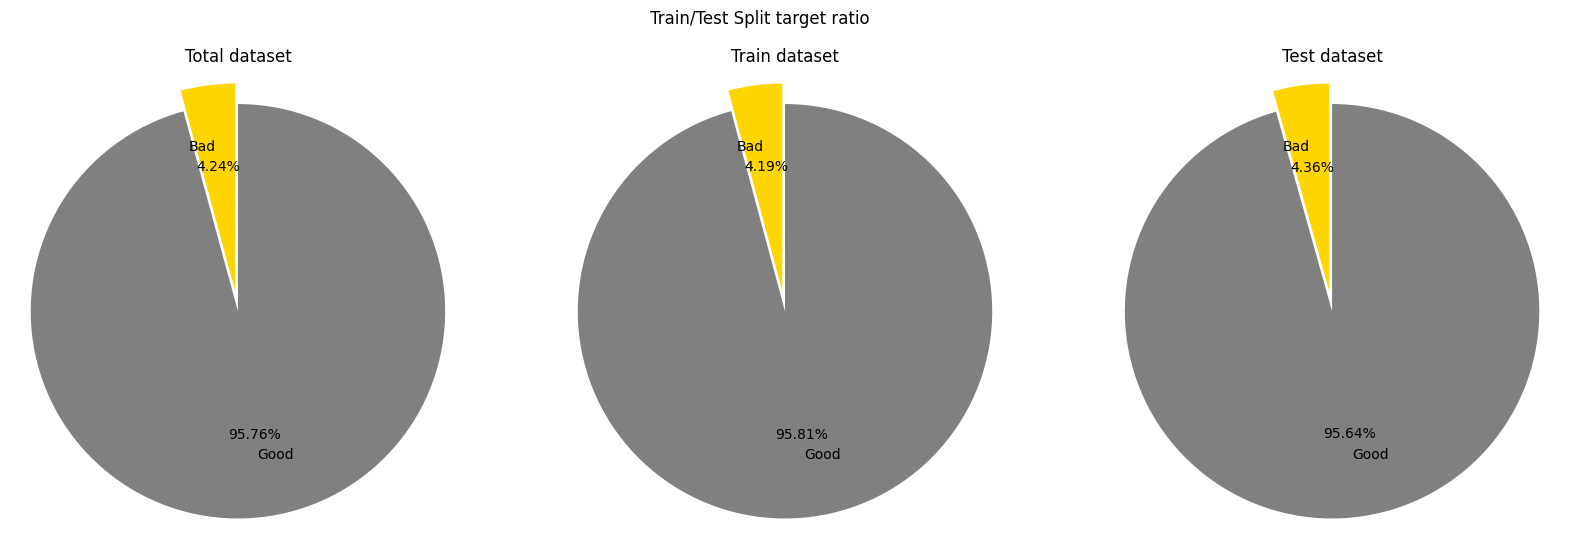

In [18]:
# Plot overall
plot_overall(df, train, test, default_col = 'ever_default_6')

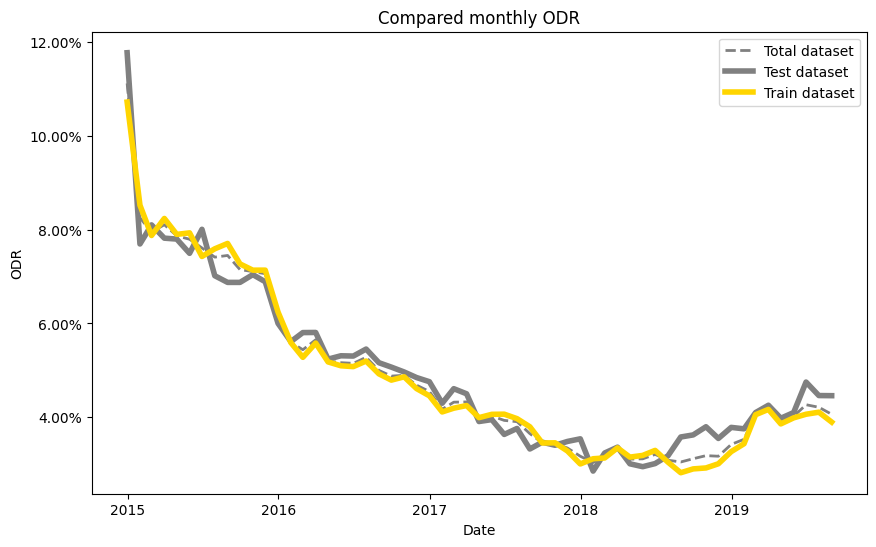

In [19]:
# Plot monthly
plot_monthly(df, train, test, default_col = 'ever_default_6', period_col = 'AS_OF_DATE')


In [20]:
# Export
train.to_parquet(
    '../data/processed/train_data.parquet',
    engine = 'pyarrow'
)

test.to_parquet(
    '../data/processed/test_data.parquet',
    engine = 'pyarrow'
)